<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
#!pip install pandas
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




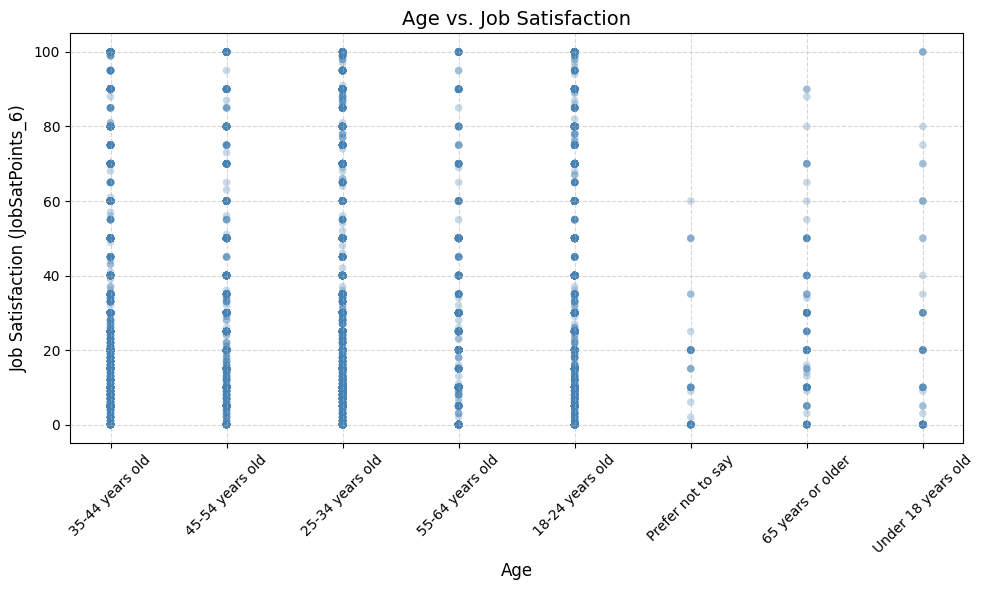

In [3]:
# Task 1.1: Scatter Plot for Age vs. Job Satisfaction

# Drop rows with missing values in the relevant columns
plot_df = df[['Age', 'JobSatPoints_6']].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['Age'], plot_df['JobSatPoints_6'], alpha=0.3, color='steelblue', edgecolors='none', s=30)
plt.title('Age vs. Job Satisfaction', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Job Satisfaction (JobSatPoints_6)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


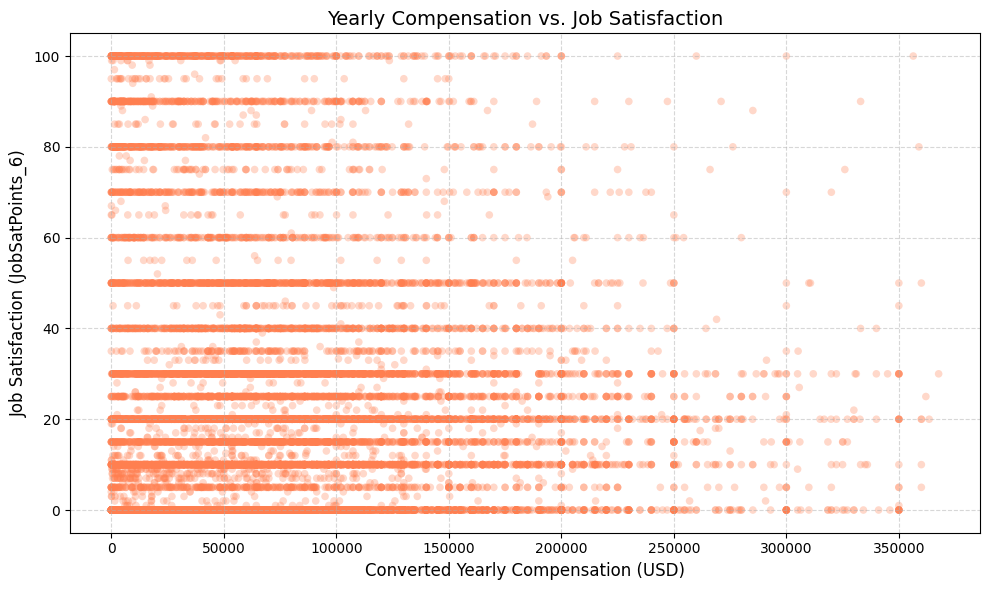

In [4]:
# Task 1.2: Scatter Plot for Compensation vs. Job Satisfaction
plot_df = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Cap compensation at 99th percentile to reduce outlier skew
cap = plot_df['ConvertedCompYearly'].quantile(0.99)
plot_df = plot_df[plot_df['ConvertedCompYearly'] <= cap]

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['ConvertedCompYearly'], plot_df['JobSatPoints_6'],
            alpha=0.3, color='coral', edgecolors='none', s=30)
plt.title('Yearly Compensation vs. Job Satisfaction', fontsize=14)
plt.xlabel('Converted Yearly Compensation (USD)', fontsize=12)
plt.ylabel('Job Satisfaction (JobSatPoints_6)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


Age
25-34 years old       12832
35-44 years old        8074
18-24 years old        4324
45-54 years old        2988
55-64 years old         986
65 years or older       119
Under 18 years old       76
Name: count, dtype: int64
[39.5 49.5 29.5 59.5 21.  65.  18. ]


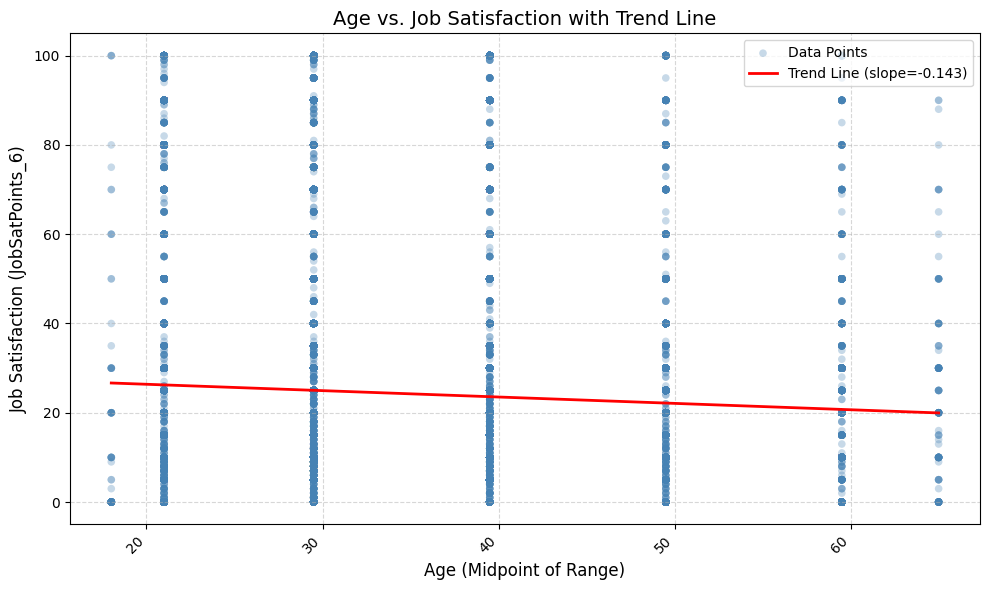

In [6]:
import numpy as np

plot_df = df[['Age', 'JobSatPoints_6']].dropna()

# Extract midpoint from age ranges like "25-34 years", "18-24 years", "65 years or older"
def age_midpoint(age_str):
    import re
    numbers = re.findall(r'\d+', str(age_str))
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    elif len(numbers) == 1:
        return int(numbers[0])
    return None

plot_df['Age_numeric'] = plot_df['Age'].apply(age_midpoint)
plot_df = plot_df.dropna(subset=['Age_numeric'])

print(plot_df['Age'].value_counts())        # check original categories
print(plot_df['Age_numeric'].unique())      # check converted midpoints

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['Age_numeric'], plot_df['JobSatPoints_6'],
            alpha=0.3, color='steelblue', edgecolors='none', s=30, label='Data Points')

# Regression line
m, b = np.polyfit(plot_df['Age_numeric'], plot_df['JobSatPoints_6'], 1)
x_line = np.linspace(plot_df['Age_numeric'].min(), plot_df['Age_numeric'].max(), 200)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend Line (slope={m:.3f})')

plt.title('Age vs. Job Satisfaction with Trend Line', fontsize=14)
plt.xlabel('Age (Midpoint of Range)', fontsize=12)
plt.ylabel('Job Satisfaction (JobSatPoints_6)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


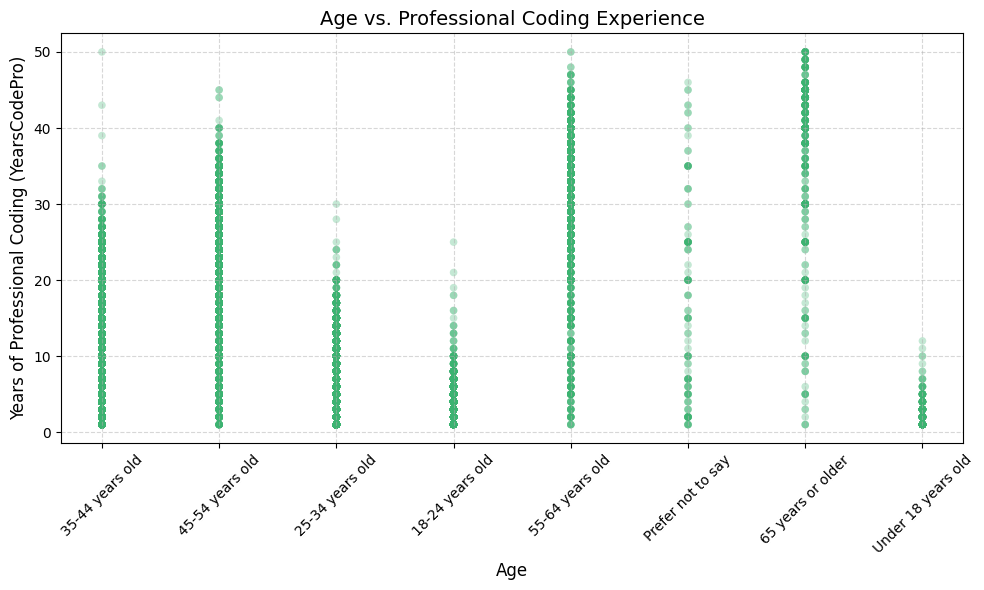

In [8]:
# Task 2.2: Scatter Plot for Age vs. Work Experience
plot_df = df[['Age', 'YearsCodePro']].dropna()
# Convert YearsCodePro to numeric (may contain strings like "Less than 1 year")
plot_df['YearsCodePro'] = pd.to_numeric(plot_df['YearsCodePro'], errors='coerce')
plot_df = plot_df.dropna()

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['Age'], plot_df['YearsCodePro'],
            alpha=0.3, color='mediumseagreen', edgecolors='none', s=30)
plt.title('Age vs. Professional Coding Experience', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Years of Professional Coding (YearsCodePro)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


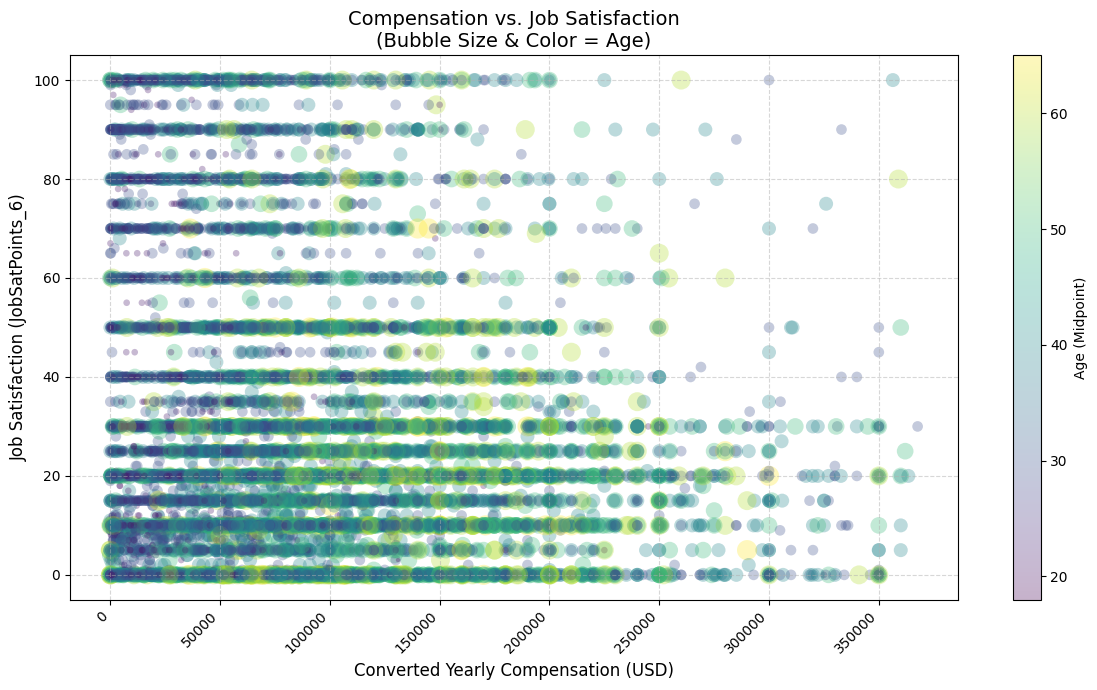

In [10]:
import re

def age_midpoint(age_str):
    numbers = re.findall(r'\d+', str(age_str))
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    elif len(numbers) == 1:
        return int(numbers[0])
    return None

plot_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age']].dropna()
cap = plot_df['ConvertedCompYearly'].quantile(0.99)
plot_df = plot_df[plot_df['ConvertedCompYearly'] <= cap]

# Convert Age strings to numeric midpoints
plot_df['Age_numeric'] = plot_df['Age'].apply(age_midpoint)
plot_df = plot_df.dropna(subset=['Age_numeric'])

# Normalize Age to bubble sizes
bubble_size = (plot_df['Age_numeric'] - plot_df['Age_numeric'].min()) / \
              (plot_df['Age_numeric'].max() - plot_df['Age_numeric'].min()) * 200 + 10

plt.figure(figsize=(12, 7))
sc = plt.scatter(plot_df['ConvertedCompYearly'], plot_df['JobSatPoints_6'],
                 s=bubble_size, alpha=0.3, c=plot_df['Age_numeric'], cmap='viridis', edgecolors='none')
plt.colorbar(sc, label='Age (Midpoint)')
plt.title('Compensation vs. Job Satisfaction\n(Bubble Size & Color = Age)', fontsize=14)
plt.xlabel('Converted Yearly Compensation (USD)', fontsize=12)
plt.ylabel('Job Satisfaction (JobSatPoints_6)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


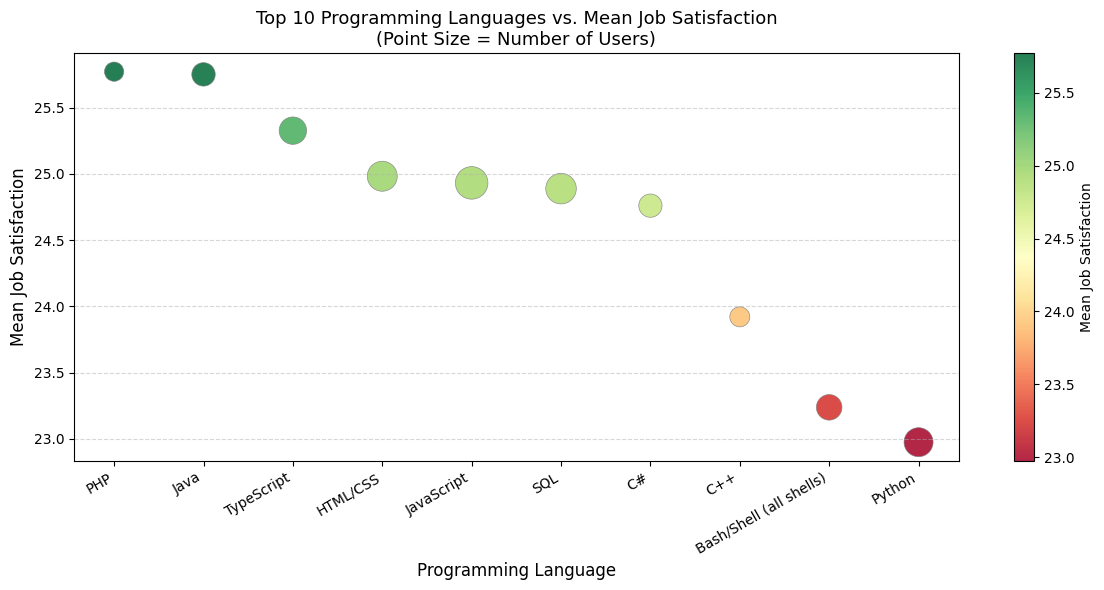

In [11]:
# Task 3.2: Popular Programming Languages vs. Job Satisfaction
plot_df = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].dropna()

# Explode multiple languages per respondent
lang_df = plot_df.assign(Language=plot_df['LanguageHaveWorkedWith'].str.split(';')).explode('Language')
lang_df['Language'] = lang_df['Language'].str.strip()

# Top 10 most common languages
top_langs = lang_df['Language'].value_counts().head(10).index
lang_df = lang_df[lang_df['Language'].isin(top_langs)]

# Aggregate: mean satisfaction + count per language
summary = lang_df.groupby('Language').agg(
    MeanSat=('JobSatPoints_6', 'mean'),
    Count=('JobSatPoints_6', 'count')
).reset_index().sort_values('MeanSat', ascending=False)

plt.figure(figsize=(12, 6))
sc = plt.scatter(summary['Language'], summary['MeanSat'],
                 s=summary['Count'] / summary['Count'].max() * 500 + 50,
                 c=summary['MeanSat'], cmap='RdYlGn', edgecolors='grey', linewidth=0.5, alpha=0.85)
plt.colorbar(sc, label='Mean Job Satisfaction')
plt.title('Top 10 Programming Languages vs. Mean Job Satisfaction\n(Point Size = Number of Users)', fontsize=13)
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Mean Job Satisfaction', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


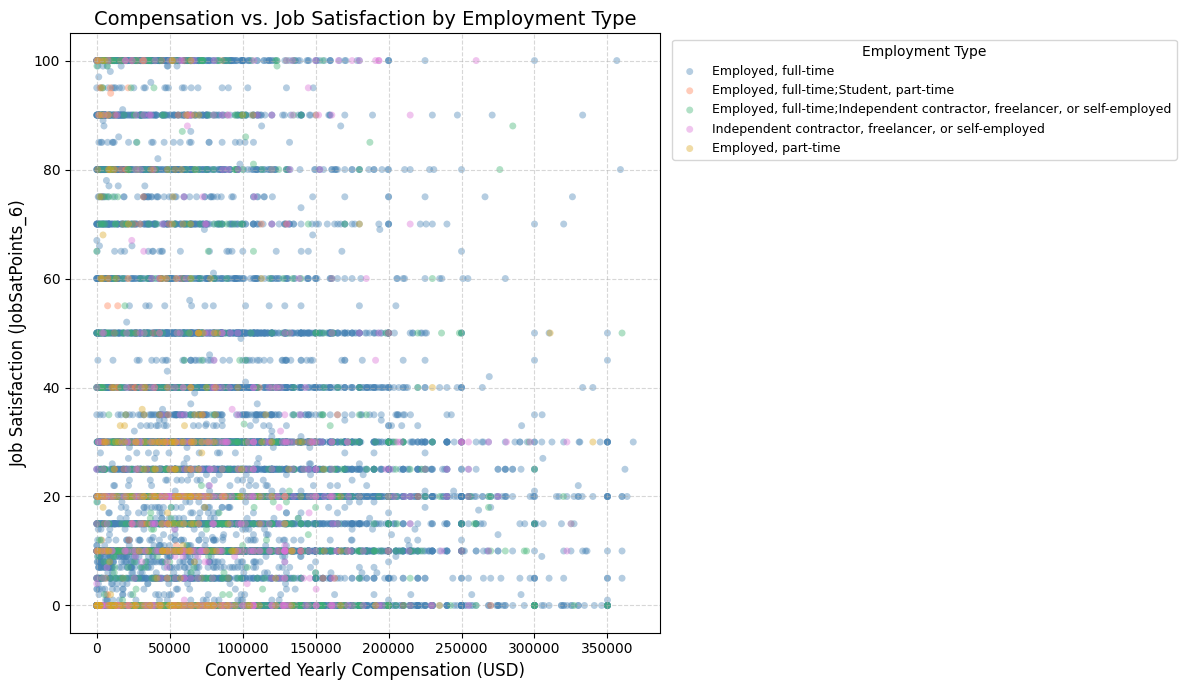

In [12]:
# Task 4.1: Compensation vs. Job Satisfaction by Employment Type
plot_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].dropna()
cap = plot_df['ConvertedCompYearly'].quantile(0.99)
plot_df = plot_df[plot_df['ConvertedCompYearly'] <= cap]

# Keep top employment types for readability
top_emp = plot_df['Employment'].value_counts().head(5).index
plot_df = plot_df[plot_df['Employment'].isin(top_emp)]

colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod']
emp_types = plot_df['Employment'].unique()

plt.figure(figsize=(12, 7))
for i, emp in enumerate(emp_types):
    subset = plot_df[plot_df['Employment'] == emp]
    plt.scatter(subset['ConvertedCompYearly'], subset['JobSatPoints_6'],
                label=emp, alpha=0.4, s=25, color=colors[i % len(colors)], edgecolors='none')

plt.title('Compensation vs. Job Satisfaction by Employment Type', fontsize=14)
plt.xlabel('Converted Yearly Compensation (USD)', fontsize=12)
plt.ylabel('Job Satisfaction (JobSatPoints_6)', fontsize=12)
plt.legend(title='Employment Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


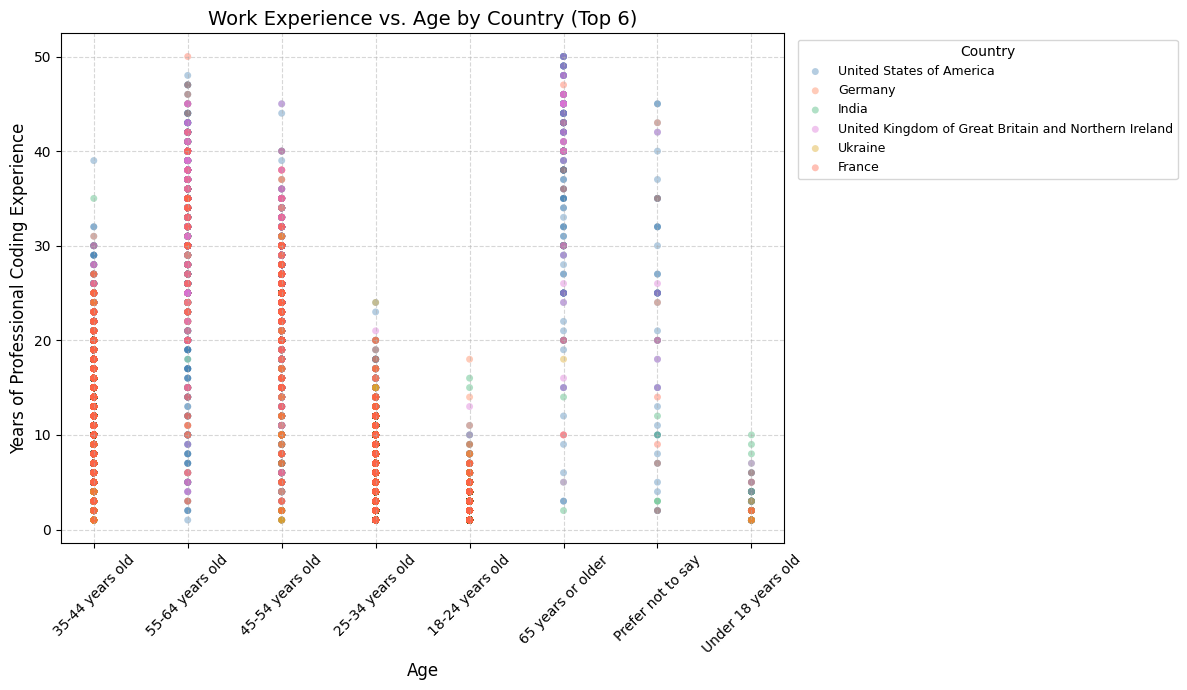

In [14]:
# Task 4.2: Work Experience vs. Age by Country (top countries)
plot_df = df[['YearsCodePro', 'Age', 'Country']].dropna()
plot_df['YearsCodePro'] = pd.to_numeric(plot_df['YearsCodePro'], errors='coerce')
plot_df = plot_df.dropna()

# Top 6 countries by respondent count
top_countries = plot_df['Country'].value_counts().head(6).index
plot_df = plot_df[plot_df['Country'].isin(top_countries)]

colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod', 'tomato']

plt.figure(figsize=(12, 7))
for i, country in enumerate(top_countries):
    subset = plot_df[plot_df['Country'] == country]
    plt.scatter(subset['Age'], subset['YearsCodePro'],
                label=country, alpha=0.4, s=25, color=colors[i], edgecolors='none')

plt.title('Work Experience vs. Age by Country (Top 6)', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Years of Professional Coding Experience', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
